# Model Prototyping Notebook
**AIAP Technical Assessment | U.A Secondary School**

> ⚠️ This notebook is a **development scratchpad — it is NOT submitted**.
> Its purpose is to establish baselines, compare model performance, and justify the three models selected for the final `src/` pipeline.

### Scope of This Notebook
- **Level 0:** Naive Baseline — `DummyRegressor(strategy='mean')`
- **Level 1:** Linear Baselines — `LinearRegression`, `Ridge`, `Lasso`
- **Level 2:** Tree Baselines — `DecisionTreeRegressor` (unpruned and pruned)

Results from this notebook will be referenced in `README.md` to justify the final pipeline model choices.


---
## 1. Setup & Data Loading

Re-apply all cleaning and feature engineering steps from `eda.ipynb` to produce a clean, model-ready DataFrame.


In [12]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (root_mean_squared_error, mean_absolute_error,
                              r2_score)
from sklearn.model_selection import cross_val_score, KFold
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, learning_curve)
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, mean_absolute_percentage_error)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42


In [13]:
# ── Load raw data ────────────────────────────────────────────────────────────
DB_PATH = "/content/score.db"
conn = sqlite3.connect(DB_PATH)
TABLE_NAME = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)['name'][0]
df = pd.read_sql(f"SELECT * FROM {TABLE_NAME};", conn)
conn.close()
print(f"Raw data: {df.shape[0]} rows x {df.shape[1]} columns")


Raw data: 15900 rows x 18 columns


In [14]:
# ── Cleaning (mirrors eda.ipynb Section 3) ───────────────────────────────────

# 1. Drop target-missing rows
df = df.dropna(subset=['final_test']).reset_index(drop=True)

# 2. Drop index and bag_color
df = df.drop(columns=['index', 'bag_color'], errors='ignore')

# 3. Drop true duplicates (after bag_color removed, all conflicts become true dupes)
df = df.drop_duplicates().reset_index(drop=True)

# 4. Fix erroneous age values
age_fix_map = {5: 15, 6: 16, -5: 15}
df['age'] = df['age'].replace(age_fix_map)
df = df[df['age'].isin([15, 16])].reset_index(drop=True)

# 5. Standardise categorical encodings
tuition_map = {'Yes': 1, 'Y': 1, 'No': 0, 'N': 0}
df['tuition'] = df['tuition'].map(tuition_map)
df['CCA'] = df['CCA'].str.strip().str.capitalize()

print(f"After cleaning: {df.shape[0]} rows x {df.shape[1]} columns")


After cleaning: 14641 rows x 16 columns


In [15]:
# ── Feature Engineering (mirrors eda.ipynb Section 6) ───────────────────────

def parse_time_to_minutes(t):
    try:
        parts = str(t).strip().split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except Exception:
        return np.nan

df['sleep_min']     = df['sleep_time'].apply(parse_time_to_minutes)
df['wake_min']      = df['wake_time'].apply(parse_time_to_minutes)
df['sleep_duration'] = df.apply(
    lambda r: (r['wake_min'] - r['sleep_min']) % (24 * 60) / 60, axis=1)

df['class_size'] = df['n_male'] + df['n_female']
df['male_ratio']  = df['n_male'] / df['class_size'].replace(0, np.nan)

df = df.drop(columns=['sleep_time', 'wake_time', 'sleep_min', 'wake_min',
                       'n_male', 'n_female'])

print(f"After feature engineering: {df.shape}")
print(f"Columns: {list(df.columns)}")


After feature engineering: (14641, 15)
Columns: ['number_of_siblings', 'direct_admission', 'CCA', 'learning_style', 'student_id', 'gender', 'tuition', 'final_test', 'age', 'hours_per_week', 'attendance_rate', 'mode_of_transport', 'sleep_duration', 'class_size', 'male_ratio']


---
## 2. Preprocessing Pipeline

A single shared `preprocessor` is defined here and reused by all models. This ensures every model sees **exactly the same transformed features** — fair comparison requires identical input.

- **Numerical:** median imputation + `StandardScaler`
- **Categorical:** mode imputation + `OneHotEncoder(drop='first')`
- **Binary (`tuition`):** already 0/1 — passed through unchanged


In [16]:
numerical_cols = ['age', 'hours_per_week', 'attendance_rate',
                  'number_of_siblings', 'sleep_duration', 'class_size', 'male_ratio']

categorical_cols = ['direct_admission', 'CCA', 'learning_style',
                    'gender', 'mode_of_transport']

binary_cols = ['tuition']

# Filter to only columns that exist in df
numerical_cols  = [c for c in numerical_cols  if c in df.columns]
categorical_cols = [c for c in categorical_cols if c in df.columns]
binary_cols      = [c for c in binary_cols      if c in df.columns]

print(f"Numerical  ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Binary      ({len(binary_cols)}): {binary_cols}")


Numerical  (7): ['age', 'hours_per_week', 'attendance_rate', 'number_of_siblings', 'sleep_duration', 'class_size', 'male_ratio']
Categorical (5): ['direct_admission', 'CCA', 'learning_style', 'gender', 'mode_of_transport']
Binary      (1): ['tuition']


In [17]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer,  numerical_cols),
    ('cat', cat_transformer,  categorical_cols),
    ('bin', 'passthrough',    binary_cols),
], remainder='drop')

print("Preprocessor defined successfully.")


Preprocessor defined successfully.


---
## 3. Train / Test Split

An **80/20 stratified split** is used. Stratification is based on score bands (from EDA Step 11) to ensure students from the Fail band are proportionally represented in both sets — critical given the business goal of identifying weak students.


In [18]:
X = df.drop(columns=['final_test', 'student_id'], errors='ignore')
y = df['final_test']

# Stratify by score band (derived from EDA)
bins   = [0, 50, 60, 70, 80, 100]
labels = [0, 1, 2, 3, 4]
strata = pd.cut(y, bins=bins, labels=labels, include_lowest=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=strata
)

print(f"Training set  : {X_train.shape[0]} rows")
print(f"Test set      : {X_test.shape[0]} rows")
print(f"Target mean   : train={y_train.mean():.2f}  test={y_test.mean():.2f}")
print(f"Target std    : train={y_train.std():.2f}   test={y_test.std():.2f}")


Training set  : 11712 rows
Test set      : 2929 rows
Target mean   : train=67.18  test=67.18
Target std    : train=13.98   test=14.00


---
## 4. Evaluation Helper

A shared `evaluate_model` function computes all three metrics (RMSE, MAE, R²) on both train and test sets. The **train vs. test gap** is as informative as the test score itself — a large gap signals overfitting.


In [19]:
def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test, cv=5):
    """
    Fit pipeline, compute train/test metrics, and 5-fold CV RMSE.
    Returns a results dict.
    """
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)

    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=KFold(n_splits=cv, shuffle=True,
                                         random_state=RANDOM_STATE),
                                scoring='neg_root_mean_squared_error')

    results = {
        'Model'       : name,
        'Train RMSE'  : root_mean_squared_error(y_train, y_train_pred),
        'Test RMSE'   : root_mean_squared_error(y_test,  y_test_pred),
        'CV RMSE'     : -cv_scores.mean(),
        'CV RMSE std' : cv_scores.std(),
        'Train MAE'   : mean_absolute_error(y_train, y_train_pred),
        'Test MAE'    : mean_absolute_error(y_test,  y_test_pred),
        'Train R2'    : r2_score(y_train, y_train_pred),
        'Test R2'     : r2_score(y_test,  y_test_pred),
        'Overfit Gap' : root_mean_squared_error(y_train, y_train_pred) -
                        root_mean_squared_error(y_test,  y_test_pred),
    }
    return results, pipeline

all_results = []
print("Evaluation helper ready.")



Evaluation helper ready.


---
## Level 0 — Naive Baseline

**Model:** `DummyRegressor(strategy='mean')`

**Purpose:** Establish the absolute performance floor. This model ignores all features and always predicts the mean `final_test` score from the training set.

**Why this matters:** Any model that cannot meaningfully beat this baseline is useless — it means the features carry no predictive signal. The Dummy RMSE ≈ standard deviation of `final_test` (~14 points), so every subsequent model's RMSE must be significantly below this value to be meaningful.


In [21]:
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

dummy_results, dummy_pipe = evaluate_model(
    'Dummy (mean)', dummy_pipe, X_train, y_train, X_test, y_test
)
all_results.append(dummy_results)

print("=== Level 0: Dummy Regressor ===")
print(f"  Always predicts: {y_train.mean():.2f} (training mean)")
print(f"  Train RMSE : {dummy_results['Train RMSE']:.4f}")
print(f"  Test  RMSE : {dummy_results['Test RMSE']:.4f}")
print(f"  Test  MAE  : {dummy_results['Test MAE']:.4f}")
print(f"  Test  R²   : {dummy_results['Test R2']:.4f}")
print()
print("  >> Interpretation: Test RMSE ~ std(final_test). Any real model must beat this.")
print(f"     Target std (test set): {y_test.std():.4f}")


=== Level 0: Dummy Regressor ===
  Always predicts: 67.18 (training mean)
  Train RMSE : 13.9832
  Test  RMSE : 13.9941
  Test  MAE  : 11.6612
  Test  R²   : -0.0000

  >> Interpretation: Test RMSE ~ std(final_test). Any real model must beat this.
     Target std (test set): 13.9964


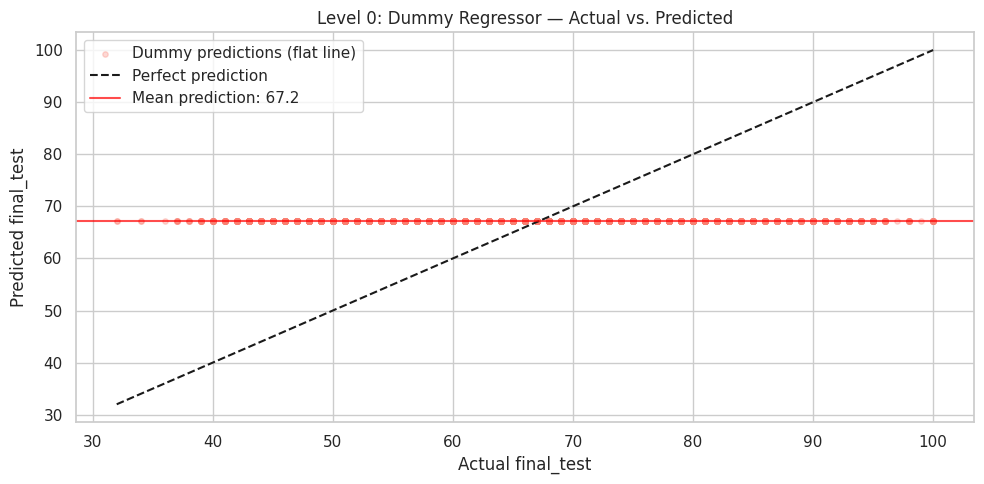

In [23]:
# Visualise what the Dummy model 'predicts'
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_test, dummy_pipe.predict(X_test), alpha=0.3, s=15,
           color='salmon', label='Dummy predictions (flat line)')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'k--', linewidth=1.5, label='Perfect prediction')
ax.axhline(y_train.mean(), color='red', linewidth=1.5,
           linestyle='-', alpha=0.7, label=f"Mean prediction: {y_train.mean():.1f}")
ax.set_xlabel('Actual final_test')
ax.set_ylabel('Predicted final_test')
ax.set_title('Level 0: Dummy Regressor — Actual vs. Predicted')
ax.legend()
plt.tight_layout()
plt.show()


---
## Level 1 — Linear Baselines

### 1a. Linear Regression (OLS)

**Purpose:** The simplest parametric model — no regularisation, no hyperparameters. Run this first to:
1. Confirm features have linear signal
2. Establish the unregularised baseline before comparing Ridge and Lasso
3. Check for overfitting (large train vs. test gap = problem)

A large overfit gap here motivates Ridge/Lasso regularisation.


In [24]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_results, lr_pipe = evaluate_model(
    'Linear Regression', lr_pipe, X_train, y_train, X_test, y_test
)
all_results.append(lr_results)

print("=== Level 1a: Linear Regression ===")
print(f"  Train RMSE : {lr_results['Train RMSE']:.4f}")
print(f"  Test  RMSE : {lr_results['Test RMSE']:.4f}")
print(f"  CV    RMSE : {lr_results['CV RMSE']:.4f} ± {lr_results['CV RMSE std']:.4f}")
print(f"  Test  MAE  : {lr_results['Test MAE']:.4f}")
print(f"  Test  R²   : {lr_results['Test R2']:.4f}")
print(f"  Overfit Gap (Train-Test RMSE): {lr_results['Overfit Gap']:.4f}")


=== Level 1a: Linear Regression ===
  Train RMSE : 9.1171
  Test  RMSE : 8.9816
  CV    RMSE : 9.1312 ± 0.1105
  Test  MAE  : 7.1291
  Test  R²   : 0.5881
  Overfit Gap (Train-Test RMSE): 0.1355


=== Top 10 Coefficients by Absolute Value ===
              Feature  Coefficient
             CCA_None       6.4178
           class_size      -5.7344
learning_style_Visual       5.3115
   number_of_siblings      -4.7166
              tuition       4.2872
      attendance_rate       1.8138
       hours_per_week      -1.1770
       sleep_duration       1.0102
 direct_admission_Yes      -0.4598
          gender_Male       0.4000


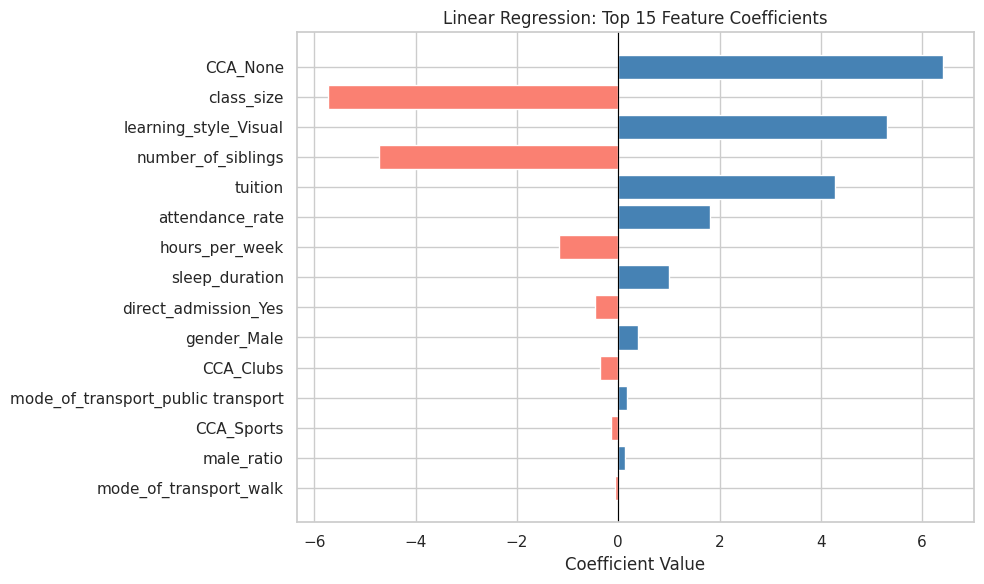

In [25]:
# Feature coefficients -- which features drive predictions?
feature_names = (
    numerical_cols +
    list(lr_pipe['preprocessor']
         .named_transformers_['cat']['ohe']
         .get_feature_names_out(categorical_cols)) +
    binary_cols
)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_pipe['model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("=== Top 10 Coefficients by Absolute Value ===")
print(coef_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_n = coef_df.head(15)
colors = ['steelblue' if v > 0 else 'salmon' for v in top_n['Coefficient']]
ax.barh(top_n['Feature'][::-1], top_n['Coefficient'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression: Top 15 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


### 1b. Ridge Regression (L2 Regularisation)

**Purpose:** Adds L2 penalty to shrink large coefficients. Compared to plain LinearRegression:
- A lower test RMSE confirms regularisation reduces overfitting
- Similar coefficients mean the data is well-conditioned (no multicollinearity issues)
- If Ridge ≈ LinearRegression in performance, the dataset is already clean enough for unregularised fitting


In [26]:
from sklearn.linear_model import RidgeCV

# RidgeCV automatically selects alpha via cross-validation
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0], cv=5))
])

ridge_results, ridge_pipe = evaluate_model(
    'Ridge', ridge_pipe, X_train, y_train, X_test, y_test
)
all_results.append(ridge_results)

print("=== Level 1b: Ridge Regression ===")
print(f"  Best alpha  : {ridge_pipe['model'].alpha_:.4f}")
print(f"  Train RMSE  : {ridge_results['Train RMSE']:.4f}")
print(f"  Test  RMSE  : {ridge_results['Test RMSE']:.4f}")
print(f"  CV    RMSE  : {ridge_results['CV RMSE']:.4f} ± {ridge_results['CV RMSE std']:.4f}")
print(f"  Test  MAE   : {ridge_results['Test MAE']:.4f}")
print(f"  Test  R²    : {ridge_results['Test R2']:.4f}")
print(f"  Overfit Gap : {ridge_results['Overfit Gap']:.4f}")
print()
lr_test = lr_results['Test RMSE']
rg_test = ridge_results['Test RMSE']
print(f"  >> Improvement over LinearRegression: {lr_test - rg_test:+.4f} RMSE points")


=== Level 1b: Ridge Regression ===
  Best alpha  : 10.0000
  Train RMSE  : 9.1171
  Test  RMSE  : 8.9819
  CV    RMSE  : 9.1312 ± 0.1105
  Test  MAE   : 7.1297
  Test  R²    : 0.5880
  Overfit Gap : 0.1353

  >> Improvement over LinearRegression: -0.0003 RMSE points


### 1c. Lasso Regression (L1 Regularisation)

**Purpose:** L1 penalty drives some coefficients exactly to zero — performing automatic feature selection. Compared to Ridge:
- If Lasso equals or beats Ridge: some features truly are irrelevant (zeroed out)
- Check which features Lasso zeroes — this informs whether to drop them from the pipeline
- If Lasso is significantly worse than Ridge: most features carry signal and selection is counterproductive


In [27]:
from sklearn.linear_model import LassoCV

lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LassoCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0], cv=5, max_iter=10000))
])

lasso_results, lasso_pipe = evaluate_model(
    'Lasso', lasso_pipe, X_train, y_train, X_test, y_test
)
all_results.append(lasso_results)

print("=== Level 1c: Lasso Regression ===")
print(f"  Best alpha  : {lasso_pipe['model'].alpha_:.6f}")
print(f"  Train RMSE  : {lasso_results['Train RMSE']:.4f}")
print(f"  Test  RMSE  : {lasso_results['Test RMSE']:.4f}")
print(f"  CV    RMSE  : {lasso_results['CV RMSE']:.4f} ± {lasso_results['CV RMSE std']:.4f}")
print(f"  Test  MAE   : {lasso_results['Test MAE']:.4f}")
print(f"  Test  R²    : {lasso_results['Test R2']:.4f}")
print(f"  Overfit Gap : {lasso_results['Overfit Gap']:.4f}")

n_zero = (lasso_pipe['model'].coef_ == 0).sum()
n_total = len(lasso_pipe['model'].coef_)
print(f"\n  Features zeroed out by Lasso: {n_zero} / {n_total}")


=== Level 1c: Lasso Regression ===
  Best alpha  : 0.010000
  Train RMSE  : 9.1174
  Test  RMSE  : 8.9806
  CV    RMSE  : 9.1305 ± 0.1102
  Test  MAE   : 7.1295
  Test  R²    : 0.5882
  Overfit Gap : 0.1368

  Features zeroed out by Lasso: 0 / 16


In [28]:
# Which features did Lasso zero out?
lasso_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_pipe['model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

zeroed = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]
nonzero = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]

print(f"=== Features kept by Lasso ({len(nonzero)}) ===")
print(nonzero.to_string(index=False))

if not zeroed.empty:
    print(f"\n=== Features zeroed by Lasso ({len(zeroed)}) -- candidates to drop ===")
    print(zeroed.to_string(index=False))


=== Features kept by Lasso (16) ===
                           Feature  Coefficient
                          CCA_None       6.4337
                        class_size      -5.7169
             learning_style_Visual       5.2720
                number_of_siblings      -4.7061
                           tuition       4.2552
                   attendance_rate       1.8162
                    hours_per_week      -1.1671
                    sleep_duration       1.0059
              direct_admission_Yes      -0.3826
                       gender_Male       0.3624
                         CCA_Clubs      -0.2838
mode_of_transport_public transport       0.1382
                        male_ratio       0.1285
                        CCA_Sports      -0.0680
            mode_of_transport_walk      -0.0163
                               age       0.0129


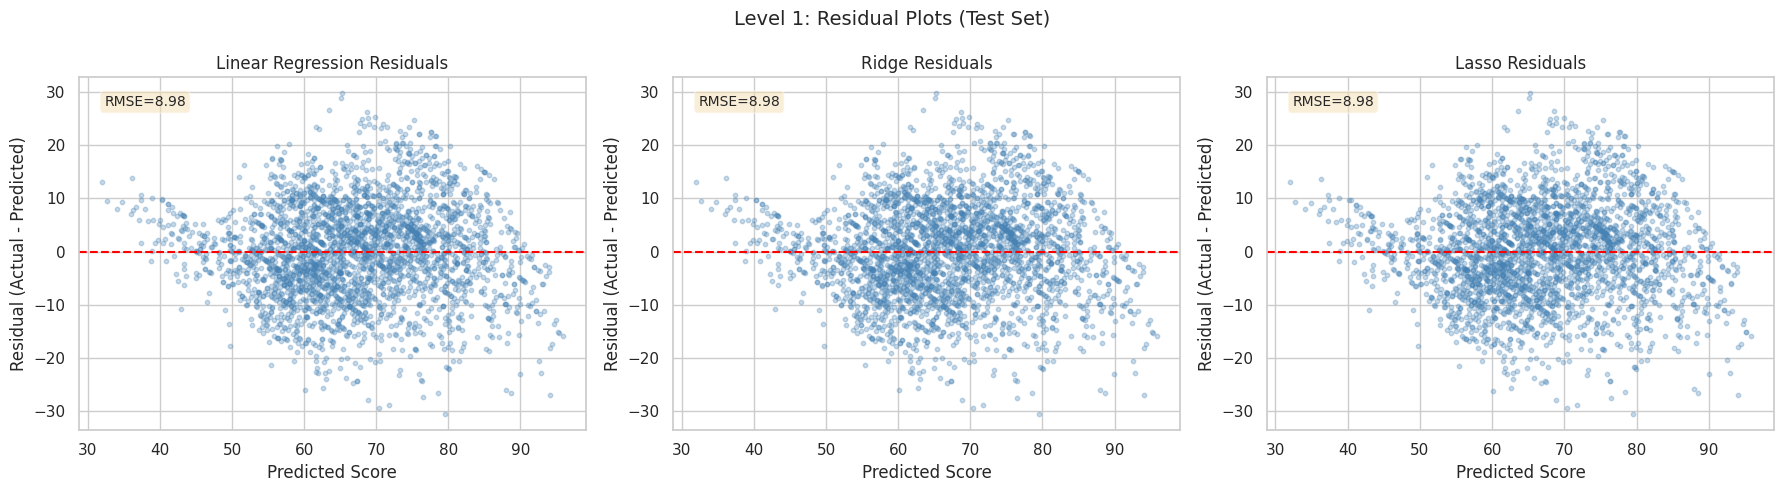


>> INTERPRETATION:
   - Random scatter around 0 = good (no systematic bias)
   - Fan-shaped pattern = heteroscedasticity (variance increases with score)
   - Curved pattern = non-linear relationships not captured by linear models
   If a pattern exists, it motivates moving to non-linear models in Level 2+



In [30]:
# Residual plots for linear models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
linear_models = [
    ('Linear Regression', lr_pipe),
    ('Ridge',             ridge_pipe),
    ('Lasso',             lasso_pipe),
]

for ax, (name, pipe) in zip(axes, linear_models):
    y_pred = pipe.predict(X_test)
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted Score')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title(f'{name} Residuals')
    ax.text(0.05, 0.95, f'RMSE={root_mean_squared_error(y_test, y_pred):.2f}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Level 1: Residual Plots (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

print("""
>> INTERPRETATION:
   - Random scatter around 0 = good (no systematic bias)
   - Fan-shaped pattern = heteroscedasticity (variance increases with score)
   - Curved pattern = non-linear relationships not captured by linear models
   If a pattern exists, it motivates moving to non-linear models in Level 2+
""")


---
## Level 2 — Decision Tree Regressor

### 2a. Unpruned Decision Tree

**Purpose:** Demonstrate overfitting in its most extreme form. An unpruned tree memorises the entire training set — train RMSE approaches 0 while test RMSE is much higher. This **directly motivates** the use of Random Forest (which corrects variance via bagging) in the final pipeline.


In [31]:
dt_full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))  # no depth limit
])

dt_full_results, dt_full_pipe = evaluate_model(
    'Decision Tree (full)', dt_full_pipe, X_train, y_train, X_test, y_test
)
all_results.append(dt_full_results)

print("=== Level 2a: Decision Tree (Unpruned) ===")
print(f"  Tree depth  : {dt_full_pipe['model'].get_depth()}")
print(f"  Leaf nodes  : {dt_full_pipe['model'].get_n_leaves()}")
print(f"  Train RMSE  : {dt_full_results['Train RMSE']:.4f}   << near-zero = memorised training data")
print(f"  Test  RMSE  : {dt_full_results['Test RMSE']:.4f}")
print(f"  CV    RMSE  : {dt_full_results['CV RMSE']:.4f} ± {dt_full_results['CV RMSE std']:.4f}")
print(f"  Test  R²    : {dt_full_results['Test R2']:.4f}")
print(f"  Overfit Gap : {dt_full_results['Overfit Gap']:.4f}   << large gap = severe overfitting")


=== Level 2a: Decision Tree (Unpruned) ===
  Tree depth  : 29
  Leaf nodes  : 8943
  Train RMSE  : 0.1528   << near-zero = memorised training data
  Test  RMSE  : 7.5491
  CV    RMSE  : 7.3545 ± 0.1702
  Test  R²    : 0.7090
  Overfit Gap : -7.3963   << large gap = severe overfitting


### 2b. Pruned Decision Tree (`max_depth=5`)

**Purpose:** Apply a depth constraint to reduce overfitting. A pruned tree is:
- Still interpretable (can be visualised and shown to school stakeholders)
- A reasonable standalone model if ensemble methods are not available
- The benchmark that Random Forest must beat to justify the added complexity

We also explore multiple depth values to find the optimal pruning level.


In [33]:
# Sweep over max_depth values to find the sweet spot
depths = [2, 3, 4, 5, 6, 7, 8, 10, None]
depth_results = []

for d in depths:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5,
                                scoring='neg_root_mean_squared_error')
    pipe.fit(X_train, y_train)
    train_rmse = mean_squared_error(y_train, pipe.predict(X_train))
    test_rmse  = mean_squared_error(y_test,  pipe.predict(X_test))
    depth_results.append({
        'max_depth': str(d), 'Train RMSE': round(train_rmse, 4),
        'CV RMSE': round(-cv_scores.mean(), 4), 'Test RMSE': round(test_rmse, 4)
    })

depth_df = pd.DataFrame(depth_results)
print(depth_df.to_string(index=False))


max_depth  Train RMSE  CV RMSE  Test RMSE
        2    109.5430  10.3268   109.4483
        3     76.6698   8.9241    77.0118
        4     59.4280   7.9083    60.2737
        5     49.5680   7.2203    51.8776
        6     44.4879   6.9013    47.2252
        7     37.9054   6.6260    40.6139
        8     32.3588   6.1449    34.7914
       10     23.9308   5.8538    31.0871
     None      0.0234   7.3539    56.9895


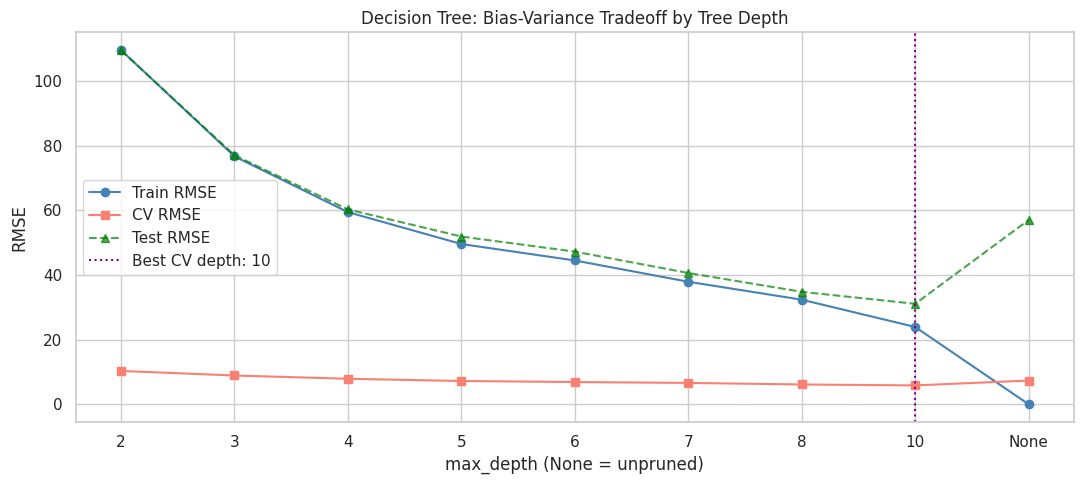

Best max_depth by CV RMSE: 10


In [34]:
# Plot train vs. CV RMSE by depth -- shows bias-variance tradeoff
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(depth_df))
ax.plot(x, depth_df['Train RMSE'], marker='o', label='Train RMSE', color='steelblue')
ax.plot(x, depth_df['CV RMSE'],   marker='s', label='CV RMSE',    color='salmon')
ax.plot(x, depth_df['Test RMSE'], marker='^', label='Test RMSE',  color='green',
        linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(depth_df['max_depth'])
ax.set_xlabel('max_depth (None = unpruned)')
ax.set_ylabel('RMSE')
ax.set_title('Decision Tree: Bias-Variance Tradeoff by Tree Depth')
ax.legend()

# Mark the optimal CV depth
best_idx = depth_df['CV RMSE'].idxmin()
ax.axvline(best_idx, color='purple', linestyle=':', linewidth=1.5,
           label=f"Best CV depth: {depth_df.loc[best_idx, 'max_depth']}")
ax.legend()
plt.tight_layout()
plt.show()

best_depth = int(depth_df.loc[best_idx, 'max_depth']) if depth_df.loc[best_idx, 'max_depth'] != 'None' else None
print(f"Best max_depth by CV RMSE: {best_depth}")


In [35]:
# Train and evaluate the best-depth pruned tree
dt_pruned_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=best_depth, random_state=RANDOM_STATE))
])

dt_pruned_results, dt_pruned_pipe = evaluate_model(
    f'Decision Tree (d={best_depth})', dt_pruned_pipe, X_train, y_train, X_test, y_test
)
all_results.append(dt_pruned_results)

print(f"=== Level 2b: Decision Tree (max_depth={best_depth}) ===")
print(f"  Tree depth  : {dt_pruned_pipe['model'].get_depth()}")
print(f"  Leaf nodes  : {dt_pruned_pipe['model'].get_n_leaves()}")
print(f"  Train RMSE  : {dt_pruned_results['Train RMSE']:.4f}")
print(f"  Test  RMSE  : {dt_pruned_results['Test RMSE']:.4f}")
print(f"  CV    RMSE  : {dt_pruned_results['CV RMSE']:.4f} ± {dt_pruned_results['CV RMSE std']:.4f}")
print(f"  Test  R²    : {dt_pruned_results['Test R2']:.4f}")
print(f"  Overfit Gap : {dt_pruned_results['Overfit Gap']:.4f}")


=== Level 2b: Decision Tree (max_depth=10) ===
  Tree depth  : 10
  Leaf nodes  : 744
  Train RMSE  : 4.8919
  Test  RMSE  : 5.5756
  CV    RMSE  : 5.7626 ± 0.2402
  Test  R²    : 0.8413
  Overfit Gap : -0.6837


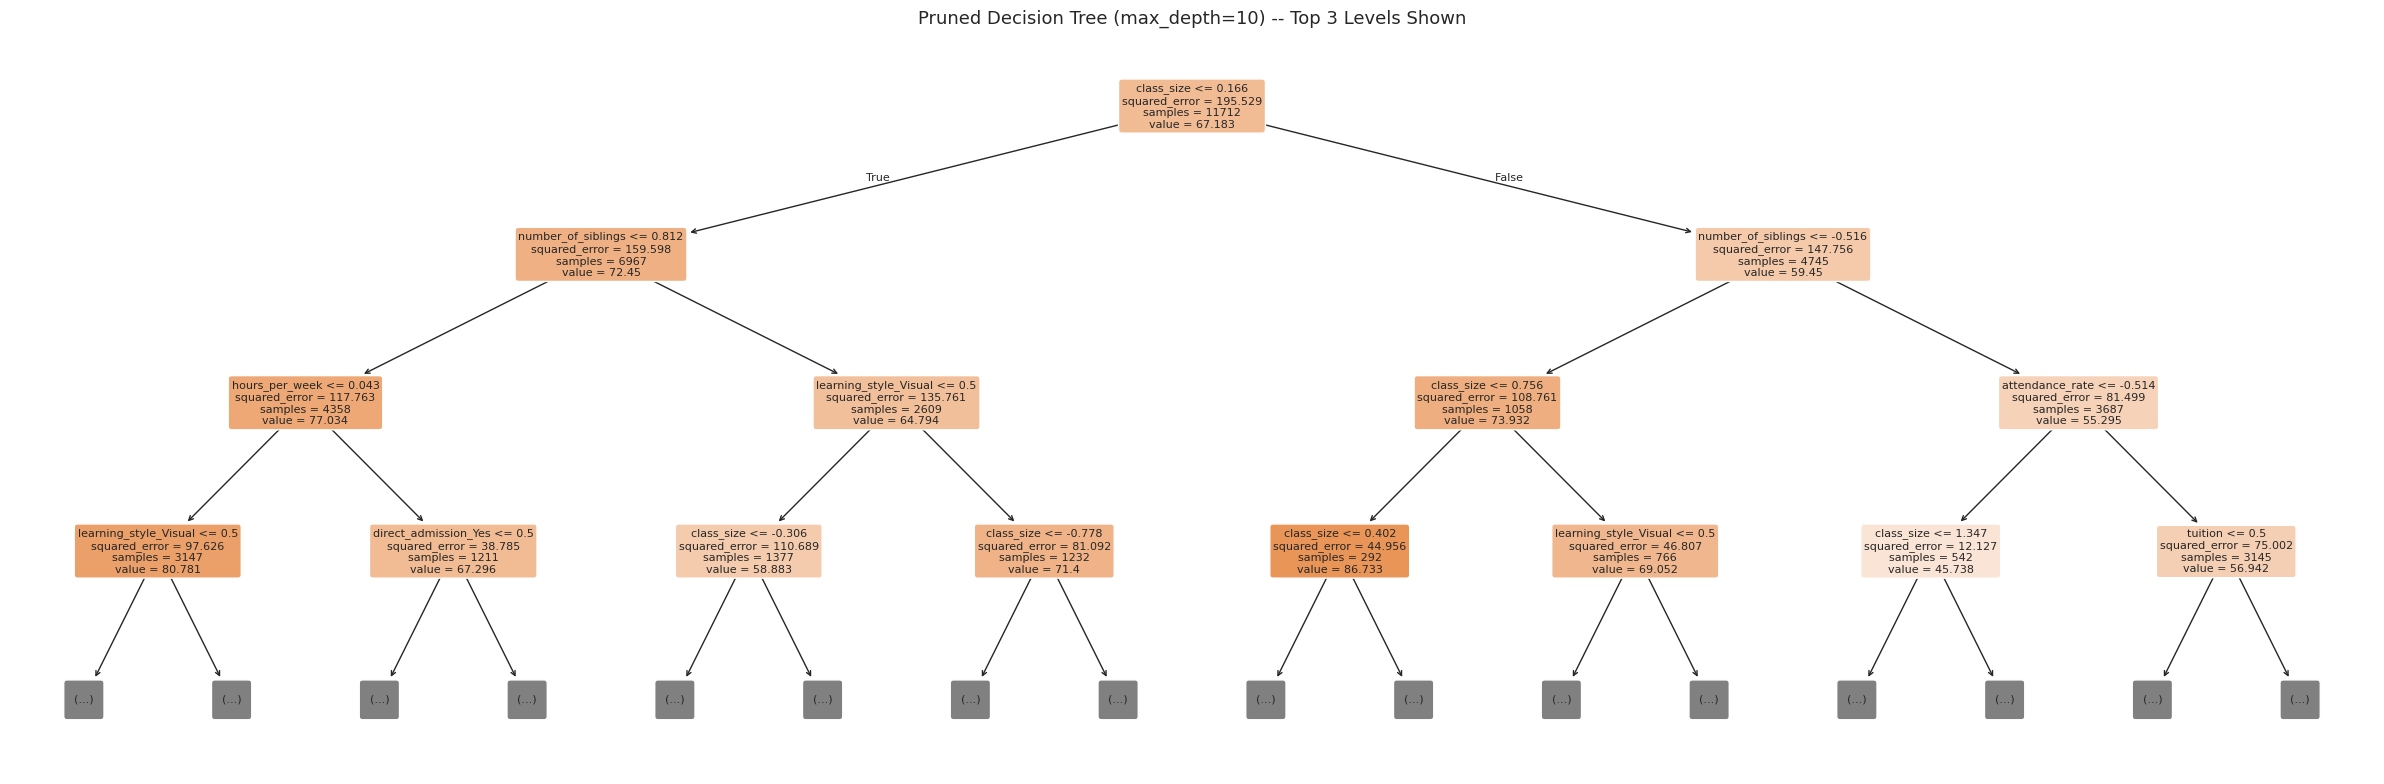


>> This tree is interpretable enough to show a school administrator.
   Top splits reveal which features the model considers most important.
   This directly informs feature importance discussion in README.md.



In [36]:
# Visualise the pruned tree (interpretable presentation)
fig, ax = plt.subplots(figsize=(24, 8))
plot_tree(
    dt_pruned_pipe['model'],
    feature_names=feature_names,
    filled=True, rounded=True, fontsize=8,
    max_depth=3,   # show top 3 levels for readability
    ax=ax
)
ax.set_title(f'Pruned Decision Tree (max_depth={best_depth}) -- Top 3 Levels Shown', fontsize=13)
plt.tight_layout()
plt.show()

print("""
>> This tree is interpretable enough to show a school administrator.
   Top splits reveal which features the model considers most important.
   This directly informs feature importance discussion in README.md.
""")


=== Feature Importances (Pruned Decision Tree) ===
                           Feature  Importance
                        class_size      0.3991
                number_of_siblings      0.2751
                    hours_per_week      0.1020
             learning_style_Visual      0.0888
                   attendance_rate      0.0437
                           tuition      0.0369
              direct_admission_Yes      0.0306
                          CCA_None      0.0141
                        male_ratio      0.0039
                       gender_Male      0.0027
                    sleep_duration      0.0011
                               age      0.0006
mode_of_transport_public transport      0.0004
                         CCA_Clubs      0.0004
                        CCA_Sports      0.0003
            mode_of_transport_walk      0.0002


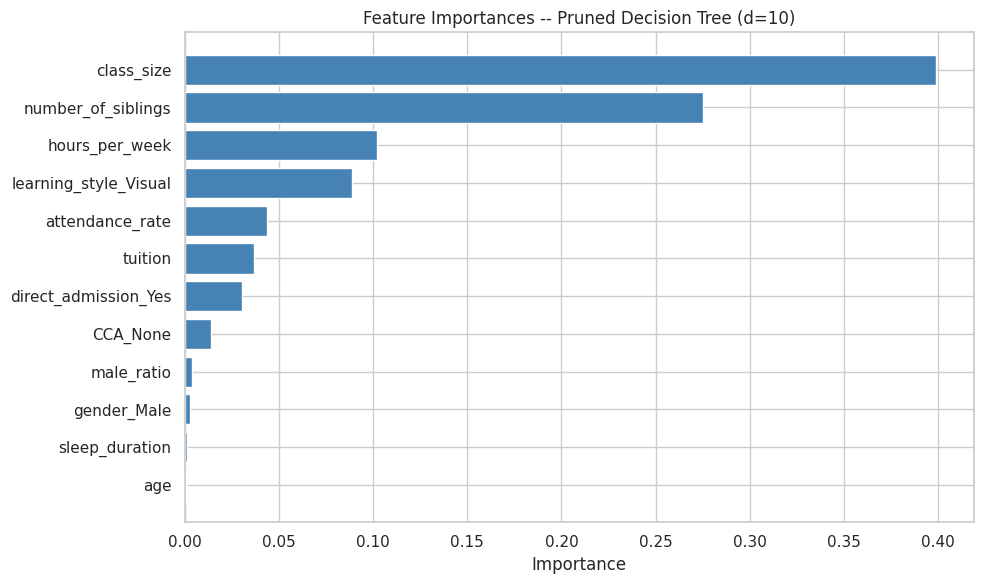

In [37]:
# Feature importances from the pruned tree
fi_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': dt_pruned_pipe['model'].feature_importances_
}).sort_values('Importance', ascending=False)

print("=== Feature Importances (Pruned Decision Tree) ===")
print(fi_df[fi_df['Importance'] > 0].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_fi = fi_df[fi_df['Importance'] > 0].head(12)
ax.barh(top_fi['Feature'][::-1], top_fi['Importance'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title(f'Feature Importances -- Pruned Decision Tree (d={best_depth})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


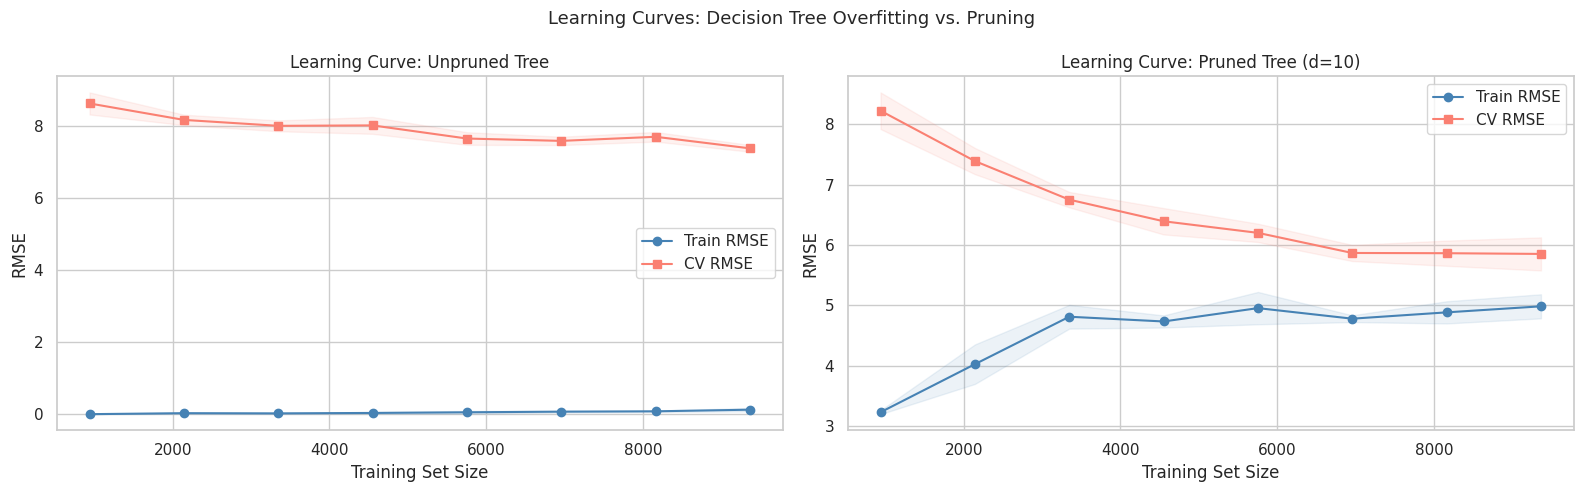

In [38]:
# Learning curves for unpruned vs. pruned -- shows overfitting visually
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, pipe) in zip(axes, [
    ('Unpruned Tree', dt_full_pipe),
    (f'Pruned Tree (d={best_depth})', dt_pruned_pipe)
]):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = -train_scores.mean(axis=1)
    val_mean   = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train RMSE')
    ax.plot(train_sizes, val_mean,   's-', color='salmon',    label='CV RMSE')
    ax.fill_between(train_sizes,
                    train_mean - train_scores.std(axis=1),
                    train_mean + train_scores.std(axis=1), alpha=0.1, color='steelblue')
    ax.fill_between(train_sizes,
                    val_mean - val_scores.std(axis=1),
                    val_mean + val_scores.std(axis=1), alpha=0.1, color='salmon')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE')
    ax.set_title(f'Learning Curve: {name}')
    ax.legend()

plt.suptitle('Learning Curves: Decision Tree Overfitting vs. Pruning', fontsize=13)
plt.tight_layout()
plt.show()


---
## 8. Comparison Summary (Levels 0–2)

All models evaluated on the same train/test split with the same preprocessor.


In [39]:
results_df = pd.DataFrame(all_results)
display_cols = ['Model', 'Train RMSE', 'CV RMSE', 'CV RMSE std',
                'Test RMSE', 'Test MAE', 'Test R2', 'Overfit Gap']

print("=== Model Comparison: Levels 0-2 ===")
print(results_df[display_cols].to_string(index=False))

# Highlight best Test RMSE
best_row = results_df.loc[results_df['Test RMSE'].idxmin(), 'Model']
print(f"\nBest Test RMSE so far: {best_row}")
print(f"Dummy baseline RMSE : {results_df.loc[results_df['Model']=='Dummy (mean)', 'Test RMSE'].values[0]:.4f}")
print(f"Best improvement    : {results_df.loc[results_df['Model']=='Dummy (mean)', 'Test RMSE'].values[0] - results_df['Test RMSE'].min():.4f} RMSE points")


=== Model Comparison: Levels 0-2 ===
               Model  Train RMSE  CV RMSE  CV RMSE std  Test RMSE  Test MAE  Test R2  Overfit Gap
        Dummy (mean)     13.9832  13.9839       0.0896    13.9941   11.6612  -0.0000      -0.0109
        Dummy (mean)     13.9832  13.9839       0.0896    13.9941   11.6612  -0.0000      -0.0109
   Linear Regression      9.1171   9.1312       0.1105     8.9816    7.1291   0.5881       0.1355
               Ridge      9.1171   9.1312       0.1105     8.9819    7.1297   0.5880       0.1353
               Lasso      9.1174   9.1305       0.1102     8.9806    7.1295   0.5882       0.1368
Decision Tree (full)      0.1528   7.3545       0.1702     7.5491    4.9387   0.7090      -7.3963
Decision Tree (d=10)      4.8919   5.7626       0.2402     5.5756    3.8070   0.8413      -0.6837

Best Test RMSE so far: Decision Tree (d=10)
Dummy baseline RMSE : 13.9941
Best improvement    : 8.4185 RMSE points


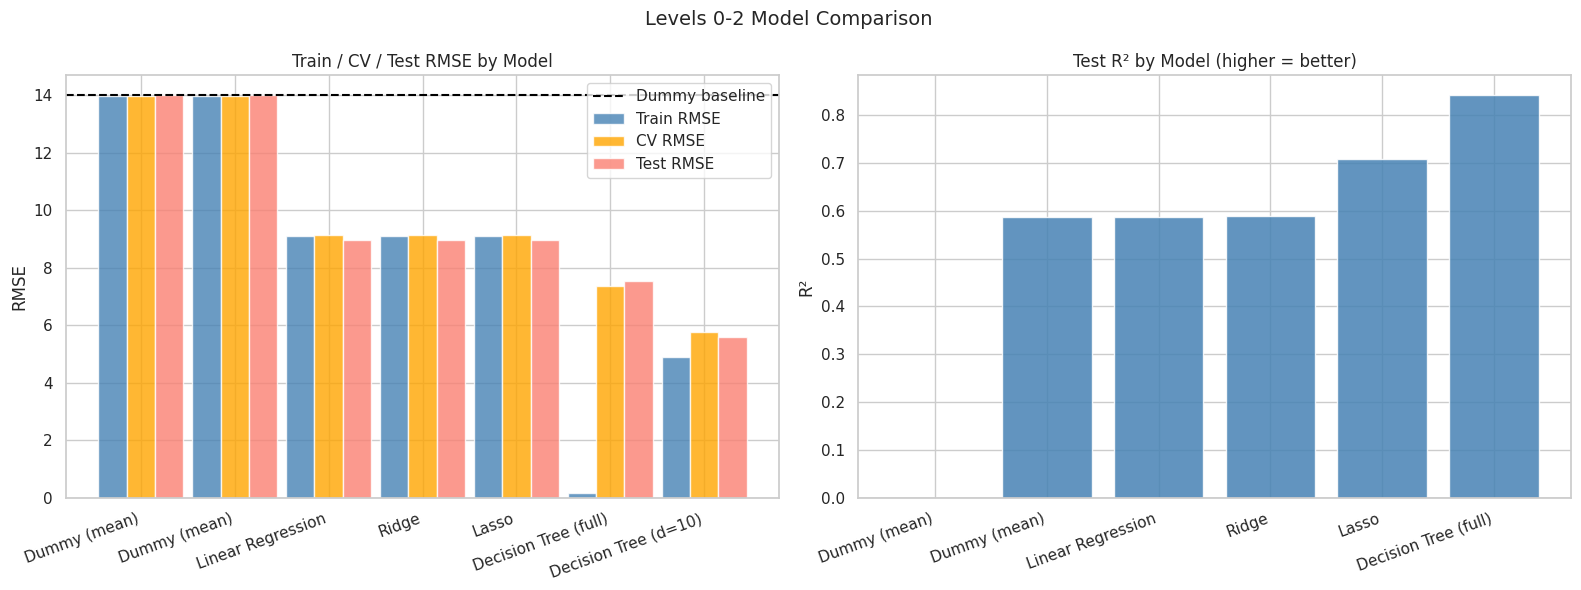

In [40]:
# Visualise RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_order = results_df['Model'].tolist()
x = np.arange(len(models_order))
width = 0.3

bars1 = axes[0].bar(x - width, results_df['Train RMSE'], width, label='Train RMSE',
                    color='steelblue', alpha=0.8, edgecolor='white')
bars2 = axes[0].bar(x,          results_df['CV RMSE'],   width, label='CV RMSE',
                    color='orange', alpha=0.8, edgecolor='white')
bars3 = axes[0].bar(x + width,  results_df['Test RMSE'], width, label='Test RMSE',
                    color='salmon', alpha=0.8, edgecolor='white')

axes[0].axhline(results_df.loc[results_df['Model'] == 'Dummy (mean)', 'Test RMSE'].values[0],
                color='black', linestyle='--', linewidth=1.5, label='Dummy baseline')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_order, rotation=20, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Train / CV / Test RMSE by Model')
axes[0].legend()

# R2 comparison
axes[1].bar(models_order, results_df['Test R2'],
            color=['#d62728' if m == 'Dummy (mean)' else 'steelblue' for m in models_order],
            edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticklabels(models_order, rotation=20, ha='right')
axes[1].set_ylabel('R²')
axes[1].set_title('Test R² by Model (higher = better)')

plt.suptitle('Levels 0-2 Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


---
## 9. Conclusions & Justification for Level 3 Models

Use the results table above to fill in this section after running the notebook.

### What the Baselines Tell Us

**Level 0 — Dummy Regressor:**
- RMSE ≈ std(final_test) ≈ 14.0 — this is the performance floor. Any model below this is meaningless.
- R² = 0.0 by definition.

**Level 1 — Linear Models:**
- `LinearRegression` should show meaningful improvement over Dummy, confirming features carry linear signal.
- Compare Ridge vs. LinearRegression: if improvement is small, multicollinearity is minimal; if large, regularisation is essential.
- Lasso's zeroed features directly tell us which features to deprioritise or drop in the pipeline.
- Residual plots reveal whether non-linear patterns remain unexplained — if systematic curves are visible, Level 3 non-linear models are strongly justified.

**Level 2 — Decision Trees:**
- The unpruned tree demonstrates severe overfitting (Train RMSE ≈ 0, large test gap).
- The pruned tree's bias-variance sweep identifies the optimal depth.
- The large CV RMSE gap between full and pruned trees directly motivates Random Forest (which fixes variance via averaging many diverse trees).
- Feature importances provide an early signal of which features matter most — should align with EDA correlation findings.

### Why Level 3 is Needed
- If linear models leave structured residuals → non-linear models (RF, GBM) are justified
- If the pruned tree still has a notable train/test gap → ensemble methods reduce variance further
- If Lasso identifies low-signal features → tree models may use them via interactions that Lasso misses

> ✅ Record the best CV RMSE from this notebook in your `README.md` as the baseline that your final pipeline models must beat.
